# Predicting Term Deposit Subscriptions: Bank Marketing Classification

**Final Project – Supervised Machine Learning: Classification**

*Prepared for: Head of Analytics*

## Executive Summary

* The goal of this analysis is to predict which clients are most likely to subscribe to a term deposit before the bank contacts them, allowing limited calling resources to be focused on higher-potential customers.
* The recommended model is the **balanced Random Forest**, which achieved a test ROC-AUC of **0.802** and an F1 score of **0.474**. It provided a better balance between precision and recall than logistic regression and generalized much better than the unrestricted decision tree.
* The model has practical targeting value: calling only the **top 20%** of clients ranked by predicted probability would reach approximately **62% of all actual subscribers**, with a success rate of around **36%**, compared with an overall subscription rate of only 11.7%.
* Previous campaign success was the strongest behavioural signal: clients with a previous successful outcome subscribed at **64.7%**, around 5.5 times the overall rate. The youngest clients and those over 60 also showed relatively high response rates, while repeatedly contacting the same customer was associated with lower success.
* Campaign timing may also matter. May had the greatest call volume but the lowest subscription rate, while several lower-volume months showed much higher success rates, suggesting that the bank should test whether reallocating campaign activity by month improves results.
* The main limitation is that the data comes from Portuguese bank campaigns conducted between 2008 and 2010, so customer behaviour and economic conditions may no longer reflect the current market. The model should therefore be retrained and validated on recent campaign data before operational use.

## Data Description

This project uses the **Bank Marketing dataset from the UCI Machine Learning Repository (ID 222)**, based on telephone marketing campaigns conducted by a Portuguese bank between 2008 and 2010. The dataset contains **45,211 client observations** and **16 original predictor variables**. The target variable, `y`, indicates whether a client subscribed to a term deposit. Only **11.7%** of clients subscribed, making the classification problem substantially imbalanced.

The predictors cover three main types of information:

* **Client profile:** age, job, marital status, education, account balance, housing loan, personal loan and credit default status.
* **Current campaign:** contact method, month, day of the month, and number of contacts made during the campaign.
* **Previous campaigns:** number of previous contacts, days since the previous contact (`pdays`) and the previous campaign outcome (`poutcome`).

Before modelling, `duration` was removed because call duration is only known after a call has occurred, meaning it would not be available when deciding whom to contact and would introduce target leakage. Missing or unspecified categorical information was retained as `"unknown"` rather than deleting observations, and a new `previously_contacted` feature was created to distinguish clients with prior campaign contact. Categorical variables were one-hot encoded, resulting in **42 modelling features**, and the data was divided using a **stratified 80/20 train-test split** so that the proportion of subscribers was preserved in both samples.

## Objective

The objective of this project is to develop a classification model that predicts which clients are most likely to subscribe to a term deposit before they are contacted. This would allow the bank to prioritise higher-potential customers rather than using limited call-centre capacity on large numbers of low-probability clients. Better targeting could reduce unnecessary calls while also lowering the risk of missing customers who are likely to respond positively. Several classification approaches are compared, including logistic regression, decision trees and Random Forest, with model selection based on both predictive performance and practical usefulness for customer targeting.

## Analytical Approach and Model Development

### Loading the data
The dataset is downloaded directly from the UCI Machine Learning Repository.

In [1]:
!pip install -q ucimlrepo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

bank = fetch_ucirepo(id=222)

X = bank.data.features
y = bank.data.targets

print(X.shape, y.shape)

(45211, 16) (45211, 1)


### Data structure and quality
Checking column types and missing values. `poutcome` is missing for clients who were never contacted in a previous campaign (`pdays = -1`), so its missing values carry meaning rather than being random gaps.

In [3]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   age          45211 non-null  int64
 1   job          44923 non-null  str  
 2   marital      45211 non-null  str  
 3   education    43354 non-null  str  
 4   default      45211 non-null  str  
 5   balance      45211 non-null  int64
 6   housing      45211 non-null  str  
 7   loan         45211 non-null  str  
 8   contact      32191 non-null  str  
 9   day_of_week  45211 non-null  int64
 10  month        45211 non-null  str  
 11  duration     45211 non-null  int64
 12  campaign     45211 non-null  int64
 13  pdays        45211 non-null  int64
 14  previous     45211 non-null  int64
 15  poutcome     8252 non-null   str  
dtypes: int64(7), str(9)
memory usage: 5.5 MB


In [4]:
X.isna().sum()

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
dtype: int64

### Class distribution
Only 11.7% of clients subscribed. A model that always predicted "no" would therefore be 88.3% accurate while finding no subscribers, so **accuracy alone is misleading** here. Models are compared mainly on **precision, recall, F1 and ROC-AUC**.

In [5]:
y = y['y']
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


### Data cleaning and feature engineering
* `duration` is removed to prevent target leakage (it is only known after the call).
* Missing categorical values are labelled `"unknown"`.
* `pdays = -1` is a code for "never contacted"; a `previously_contacted` flag is created and the code is replaced with 0 so it is not mistaken for a very recent contact.
* The target is converted to 1 (subscribed) and 0 (not subscribed).

In [6]:
X = X.drop(columns=['duration'])

X = X.fillna('unknown')

X['previously_contacted'] = (X['pdays'] != -1).astype(int)
X['pdays'] = X['pdays'].replace(-1, 0)

y = (y == 'yes').astype(int)

print(X.shape)
print(X.isna().sum().sum())
print(y.value_counts())

(45211, 16)
0
y
0    39922
1     5289
Name: count, dtype: int64


### Encoding and train-test split
Categorical variables are one-hot encoded. The split is **stratified** so the training and test sets keep the same 11.7% share of subscribers.

In [7]:
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
print(cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype=int)
print(X_encoded.shape)

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


(45211, 42)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean().round(4), y_test.mean().round(4))

(36168, 42) (9043, 42)
0.117 0.117


## Model Comparison and Selection

Four classification models were trained and evaluated on the same test set:

1. **Logistic Regression** – a linear, interpretable baseline.
2. **Logistic Regression (balanced)** – the same model with class weights, so missing a subscriber costs more than a false alarm.
3. **Decision Tree (no depth limit)** – a non-linear model, included to test how a fully grown tree generalises.
4. **Random Forest (balanced)** – 300 trees with a minimum of 10 clients per leaf and class weights, to reduce overfitting and address class imbalance.

Each model is evaluated with accuracy, precision, recall, F1 and ROC-AUC on the test set, plus training ROC-AUC to check for overfitting.

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
log_reg.fit(X_train, y_train);

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

results = []

def evaluate(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    train_prob = model.predict_proba(X_train)[:, 1]

    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'train_roc_auc': roc_auc_score(y_train, train_prob)
    })
    print(confusion_matrix(y_test, y_pred))
    return pd.DataFrame(results).round(3)

evaluate('Logistic Regression', log_reg)

[[7890   95]
 [ 867  191]]


,model,accuracy,precision,recall,f1,roc_auc,train_roc_auc
0,Logistic Regression,0.894,0.668,0.181,0.284,0.772,0.767


In [11]:
log_reg_bal = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced')
)
log_reg_bal.fit(X_train, y_train)

evaluate('Logistic Regression (balanced)', log_reg_bal)

[[6176 1809]
 [ 399  659]]


,model,accuracy,precision,recall,f1,roc_auc,train_roc_auc
0,Logistic Regression,0.894,0.668,0.181,0.284,0.772,0.767
1,Logistic Regression (balanced),0.756,0.267,0.623,0.374,0.772,0.768


The plain logistic regression found only 191 of 1,058 subscribers (recall 0.181): with 88% "no" in the training data, it learned that predicting "no" is almost always safe. Adding class weights raised recall to 0.623 at the cost of precision and accuracy, while ROC-AUC stayed at 0.772 — the model ranks clients in the same order, and only the decision threshold moved.

In [12]:
from sklearn.tree import DecisionTreeClassifier

tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

evaluate('Decision Tree (no limit)', tree_full)

[[7162  823]
 [ 722  336]]


,model,accuracy,precision,recall,f1,roc_auc,train_roc_auc
0,Logistic Regression,0.894,0.668,0.181,0.284,0.772,0.767
1,Logistic Regression (balanced),0.756,0.267,0.623,0.374,0.772,0.768
2,Decision Tree (no limit),0.829,0.290,0.318,0.303,0.607,1.000


The unrestricted decision tree scored a perfect 1.000 ROC-AUC on the training data but only 0.607 on the test set. This is clear **overfitting**: the tree memorised individual training clients rather than learning patterns that generalise.

In [13]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
forest.fit(X_train, y_train)

evaluate('Random Forest (balanced)', forest)

[[7071  914]
 [ 446  612]]


,model,accuracy,precision,recall,f1,roc_auc,train_roc_auc
0,Logistic Regression,0.894,0.668,0.181,0.284,0.772,0.767
1,Logistic Regression (balanced),0.756,0.267,0.623,0.374,0.772,0.768
2,Decision Tree (no limit),0.829,0.290,0.318,0.303,0.607,1.000
3,Random Forest (balanced),0.850,0.401,0.578,0.474,0.802,0.915


### Model selection

The balanced Random Forest is the strongest model. Its test ROC-AUC is 0.802, compared with 0.772 for balanced logistic regression, and its F1 score improves from 0.374 to 0.474. The forest also has much higher precision (0.401 vs 0.267), although its recall is slightly lower (0.578 vs 0.623), so it makes a better overall trade-off between finding positive cases and avoiding false positives.

There is still some evidence of overfitting in the Random Forest because its train ROC-AUC is 0.915 compared with 0.802 on the test set, a gap of about 0.113. However, this is far less severe than the unrestricted Decision Tree, which achieved a perfect 1.000 train ROC-AUC but only 0.607 on the test set, a gap of 0.393. This shows that averaging many trees in the Random Forest substantially reduces the variance and overfitting of a single decision tree, although the almost identical train and test scores of balanced logistic regression still show that logistic regression generalizes more consistently. Because the forest's **test** performance is the best of all four models, its remaining gap is acceptable, and it is selected as the final model.

**Selected model: Random Forest (balanced).**

## Key Findings and Insights

### Most important features
Permutation importance measures how much the model's test ROC-AUC drops when each feature is randomly shuffled. It is used instead of the forest's built-in importance, which is biased towards numeric features with many distinct values.

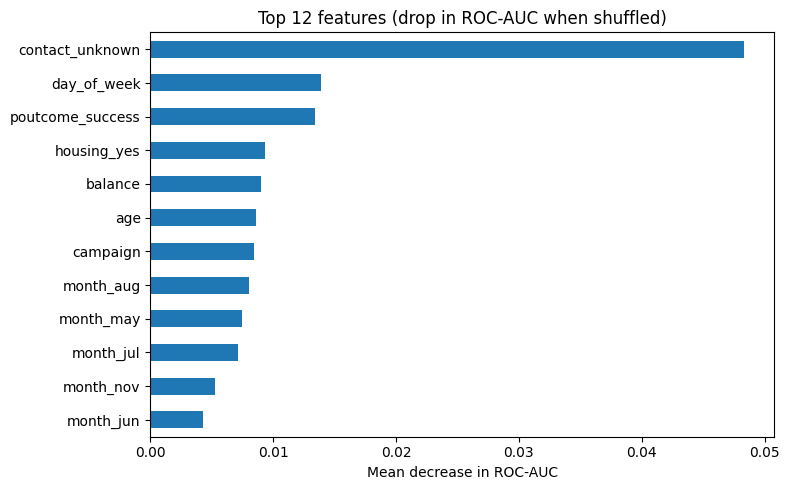

contact_unknown     0.0483
day_of_week         0.0139
poutcome_success    0.0134
housing_yes         0.0093
balance             0.0090
age                 0.0086
campaign            0.0084
month_aug           0.0080
month_may           0.0074
month_jul           0.0071
month_nov           0.0052
month_jun           0.0043
dtype: float64

In [14]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    forest, X_test, y_test,
    scoring='roc_auc', n_repeats=5, random_state=42, n_jobs=-1
)

importance = pd.Series(perm.importances_mean, index=X_test.columns)
top = importance.sort_values(ascending=False).head(12)

top.sort_values().plot(kind='barh', figsize=(8, 5))
plt.title('Top 12 features (drop in ROC-AUC when shuffled)')
plt.xlabel('Mean decrease in ROC-AUC')
plt.tight_layout()
plt.show()

top.round(4)

* **`contact_unknown`** is the strongest feature, but it is likely a **data-recording artefact**: the contact method was mostly unrecorded in May (58%) and June (85%), a period with low success rates. It reflects *when* clients were contacted rather than client behaviour (see Limitations).
* **`day_of_week`** is actually the **day of the month** (1–31), so its importance likely reflects campaign timing.
* **Previous campaign success, housing loans, balance, age, number of calls and month** carry the genuine behavioural and campaign signals.

### Subscription rates by client group

In [15]:
df_view = X.copy()
df_view['subscribed'] = y

for col in ['poutcome', 'contact', 'housing']:
    print(df_view.groupby(col)['subscribed'].mean().round(3), '\n')

print(df_view.groupby(pd.cut(df_view['campaign'], [0, 1, 2, 3, 5, 100]), observed=True)['subscribed'].mean().round(3), '\n')
print(df_view.groupby(pd.cut(df_view['age'], [0, 25, 35, 45, 60, 100]), observed=True)['subscribed'].mean().round(3), '\n')
print(df_view.groupby('month')['subscribed'].agg(['mean', 'size']).round(3).sort_values('mean'))

poutcome
failure    0.126
other      0.167
success    0.647
unknown    0.092
Name: subscribed, dtype: float64 

contact
cellular     0.149
telephone    0.134
unknown      0.041
Name: subscribed, dtype: float64 

housing
no     0.167
yes    0.077
Name: subscribed, dtype: float64 

campaign
(0, 1]      0.146
(1, 2]      0.112
(2, 3]      0.112
(3, 5]      0.086
(5, 100]    0.058
Name: subscribed, dtype: float64 

age
(0, 25]      0.240
(25, 35]     0.120
(35, 45]     0.094
(45, 60]     0.098
(60, 100]    0.423
Name: subscribed, dtype: float64 

        mean   size
month              
may    0.067  13766
jul    0.091   6895
jan    0.101   1403
jun    0.102   5341
nov    0.102   3970
aug    0.110   6247
feb    0.166   2649
apr    0.197   2932
oct    0.438    738
sep    0.465    579
dec    0.467    214
mar    0.520    477


The subscription rates reveal several clear patterns in customer response. Clients who had previously responded successfully to a campaign had a **64.7%** subscription rate, compared with only 11.7% overall, making them about **5.5 times** more likely to subscribe. Clients without a housing loan subscribed at 16.7%, more than double the 7.7% rate of those with one. Age also showed an interesting pattern: the youngest customers (25 and under) had a 24% success rate, while customers over 60 had the highest rate at 42%, which may reflect groups such as students and retirees having different financial needs or greater availability to engage with calls. Repeated contact appeared less effective, as the success rate fell from 14.6% after one call to only 5.8% for customers contacted six or more times, suggesting that repeatedly calling the same customer may have diminishing returns — although this may partly reflect that hesitant clients are the ones who receive repeated calls. Finally, May had the highest call volume with 13,766 calls but the lowest success rate at 6.7%, while March, September, October and December achieved much higher success rates of around 44–52% despite having far fewer calls. This suggests that campaign timing could matter substantially, although the bank should test this pattern further before changing its calling strategy because the differences may also reflect which customers were contacted during those months.

### Practical value: targeting the highest-probability clients

In [16]:
probs = forest.predict_proba(X_test)[:, 1]

ranked = pd.DataFrame({'prob': probs, 'actual': y_test.values})
ranked = ranked.sort_values('prob', ascending=False)

total_subscribers = ranked['actual'].sum()

for share in [0.1, 0.2, 0.3]:
    n = int(len(ranked) * share)
    top = ranked.head(n)
    captured = top['actual'].sum() / total_subscribers
    rate = top['actual'].mean()
    print(f'Call top {int(share*100)}%: reach {captured:.0%} of subscribers, success rate {rate:.0%}')

Call top 10%: reach 43% of subscribers, success rate 50%
Call top 20%: reach 62% of subscribers, success rate 36%
Call top 30%: reach 71% of subscribers, success rate 28%


These results show that the model could help the bank target its calls much more efficiently than contacting clients at random. By calling only the top 10% of clients ranked by the model, the bank could reach **43%** of all actual subscribers, with a **50%** success rate — about four times the overall subscription rate of 11.7%. Calling the **top 20%** reaches **62%** of subscribers with a 36% success rate (about three times the base rate), which is likely the most practical balance between reach and efficiency. Even if the bank expanded outreach to the top 30%, it would still capture 71% of subscribers while maintaining a 28% success rate, suggesting that the model could reduce unnecessary calls while still reaching most potential customers. These estimates come from a single test split and assume future clients behave like past ones.

## Limitations and Next Steps

**Limitation 1 – Data-recording artefacts:** The feature `contact_unknown` appeared as one of the strongest predictors, but this may reflect how the campaign data was recorded during certain months, especially May and June, rather than a genuine customer characteristic. **Next step:** I would investigate the relationship between contact type, month and campaign procedures, and either remove or redefine this variable if it mainly represents a recording artefact.

**Limitation 2 – Class imbalance and false positives:** Only about 11.7% of clients subscribed, so the dataset is highly imbalanced. Class weighting improved the model's ability to identify subscribers, but the Random Forest precision is still only about 40%, meaning roughly 6 out of every 10 clients flagged as positive would not actually subscribe. **Next step:** I would test different probability thresholds based on the bank's business costs and also compare resampling approaches such as SMOTE to see whether precision and recall can be balanced more effectively.

**Limitation 3 – Remaining overfitting:** The Random Forest still shows some overfitting, with a training ROC-AUC of 0.915 compared with 0.802 on the test set. Although this gap is much smaller than for the unrestricted decision tree, it suggests the forest is still learning some patterns that do not generalize perfectly. **Next step:** I would tune parameters such as `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` and the number of trees using GridSearchCV or RandomizedSearchCV with cross-validation rather than selecting settings manually.

**Limitation 4 – Reliance on one train/test split:** The reported performance is based on a single 80/20 train-test split, so the results may depend partly on which observations happened to fall into each sample. **Next step:** I would use stratified k-fold cross-validation to evaluate the model across several different splits while preserving the proportion of subscribers and non-subscribers. This would provide a more reliable estimate of out-of-sample performance.

**Limitation 5 – Missing predictors (additional data):** `duration` was correctly removed because it is only known after a call takes place, but the available variables still do not capture everything that might influence subscription behaviour, such as customer income, product holdings, account activity, digital engagement or changing economic conditions. **Next step:** I would add suitable information that is genuinely available before contact, such as customer product holdings and macroeconomic indicators at the time of the campaign.

**Limitation 6 – Alternative modelling techniques:** Only logistic regression, a decision tree and a Random Forest were compared. **Next step:** I would compare the Random Forest with more advanced classifiers such as Gradient Boosting, XGBoost or LightGBM. These models may capture more complex relationships while still allowing feature importance and targeting performance to be evaluated.

**Limitation 7 – Age of the data:** The campaigns took place between 2008 and 2010, during the global financial crisis, so customer behaviour and interest rates may differ substantially today. **Next step:** The model should be retrained and validated on recent campaign data before being used to guide real calling decisions.